In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import time
from torchvision import transforms
from PIL import Image
from skimage.metrics import peak_signal_noise_ratio as psnr_metric
from skimage.metrics import structural_similarity as ssim_metric
from scipy.stats import wasserstein_distance
from scipy.special import kl_div

from last_diff import GrainDiffusionUNet, NoiseScheduler

# ── Config ────────────────────────────────────────────────────────────────────
WEIGHTS_PATH      = "./final_model_diff_last/grain_diffusion_weights_only.pt"
ROOT_DIR          = "/home/hice1/vyadav68/scratch/grain_growth/dataset/grain_images"
IMAGE_SIZE        = 512
NUM_FUTURE_FRAMES = 3
DELTA_T           = 100
DDIM_STEPS        = 1000        # set to 1000 for full DDPM
device            = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Load Model ────────────────────────────────────────────────────────────────
model = GrainDiffusionUNet(
    num_future_frames=NUM_FUTURE_FRAMES,
    base_channels=64,
    context_dim=256,
    embed_dim=128,
).to(device)

raw   = torch.load(WEIGHTS_PATH, map_location=device)
state = {k.replace("_orig_mod.", ""): v for k, v in raw.items()}
model.load_state_dict(state)
model.eval()
print(f"Loaded: {WEIGHTS_PATH}")
print(f"Params: {sum(p.numel() for p in model.parameters()):,}")

scheduler = NoiseScheduler(num_timesteps=1000)

# ── Transforms ────────────────────────────────────────────────────────────────
grain_tf = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])
boundary_tf = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

# ── Loaders ───────────────────────────────────────────────────────────────────
def load_rgb(run_id, temp, timestep):
    p = f"{ROOT_DIR}/timestep_{timestep}/run_{run_id}_temp_{temp:.3f}_timestep_{timestep}_rgb.png"
    return grain_tf(Image.open(p).convert("RGB")).unsqueeze(0).to(device)

def load_boundary(run_id, temp, timestep):
    p = f"{ROOT_DIR}/timestep_{timestep}/run_{run_id}_temp_{temp:.3f}_timestep_{timestep}_boundary.png"
    return (1.0 - boundary_tf(Image.open(p).convert("L"))).unsqueeze(0).to(device)

# ── Helpers ───────────────────────────────────────────────────────────────────
def to_display(t):
    """(1,3,H,W) in [-1,1] → (H,W,3) in [0,1]"""
    return t[0].cpu().float().clamp(-1,1).permute(1,2,0).numpy() * 0.5 + 0.5

def get_sobel_edges(rgb_tensor):
    """(1,3,H,W) → (H,W) numpy"""
    import torch.nn.functional as F
    gray = rgb_tensor.float().clamp(-1,1).mean(dim=1, keepdim=True)
    gray = (gray + 1) / 2
    sx = torch.tensor([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=torch.float32, device=rgb_tensor.device).view(1,1,3,3)
    sy = torch.tensor([[-1,-2,-1],[0,0,0],[1,2,1]], dtype=torch.float32, device=rgb_tensor.device).view(1,1,3,3)
    mag = torch.sqrt(F.conv2d(gray,sx,padding=1)**2 + F.conv2d(gray,sy,padding=1)**2)
    return (mag / (mag.max()+1e-6)).squeeze().cpu().numpy()

# ── Inference ─────────────────────────────────────────────────────────────────
def run_inference(anchor, jump_tensor, temp_tensor, steps=DDIM_STEPS):
    canvas = torch.randn(1, NUM_FUTURE_FRAMES*3, IMAGE_SIZE, IMAGE_SIZE, device=device)

    with torch.no_grad():
        past_ctx = model.get_past_context(anchor)

        if steps == 1000:
            for t in reversed(range(1000)):
                if t % 250 == 0: print(f"  Step {t}/1000...")
                pred_noise = model(canvas, anchor, torch.tensor([t], device=device),
                                   jump_tensor, temp_tensor, precomputed_context=past_ctx)
                canvas = scheduler.ddpm_step(canvas, pred_noise, t, device)
        else:
            timesteps = torch.linspace(999, 0, steps, dtype=torch.long)
            for i, t in enumerate(timesteps):
                t_prev = timesteps[i+1].item() if i+1 < len(timesteps) else -1
                pred_noise = model(canvas, anchor, torch.tensor([t.item()], device=device),
                                   jump_tensor, temp_tensor, precomputed_context=past_ctx)
                canvas = scheduler.ddim_step(canvas, pred_noise, t.item(), t_prev, device)

    return canvas.clamp(-1, 1)

print("Cell 1 done.")

Loaded: ./final_model_diff_last/grain_diffusion_weights_only.pt
Params: 42,269,379
Cell 1 done.


Run 632 | Temp 0.515 | Anchor T=200 → Predicting T=[300, 400, 500]
  Step 750/1000...
  Step 500/1000...
  Step 250/1000...
  Step 0/1000...
Done in 19.1s

─────────────────────────────────────────────────────────────────
T             MSE       PSNR     SSIM     W-Dist       KL
─────────────────────────────────────────────────────────────────
T=300     0.0477     13.21dB   0.5220     0.0543 411.9142
T=400     0.0533     12.73dB   0.5074     0.0623 508.1970
T=500     0.0599     12.23dB   0.4962     0.0602 513.9902
─────────────────────────────────────────────────────────────────


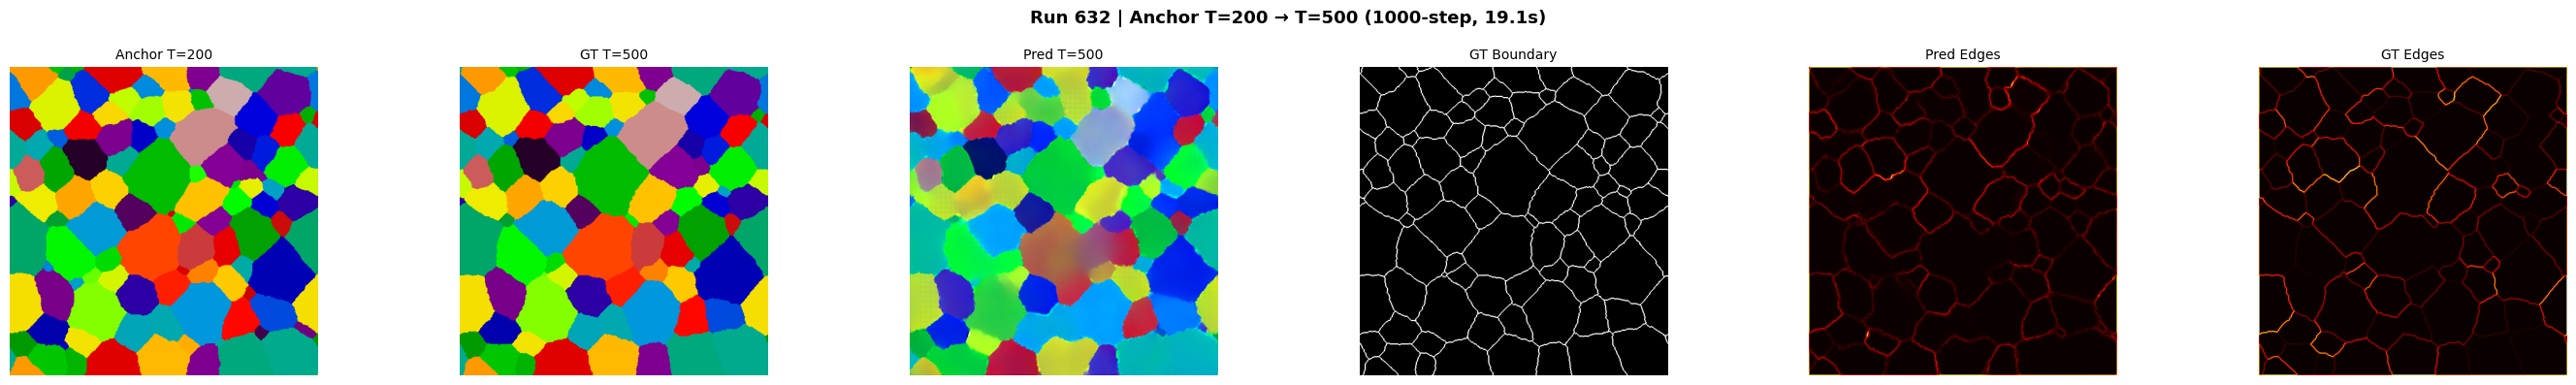

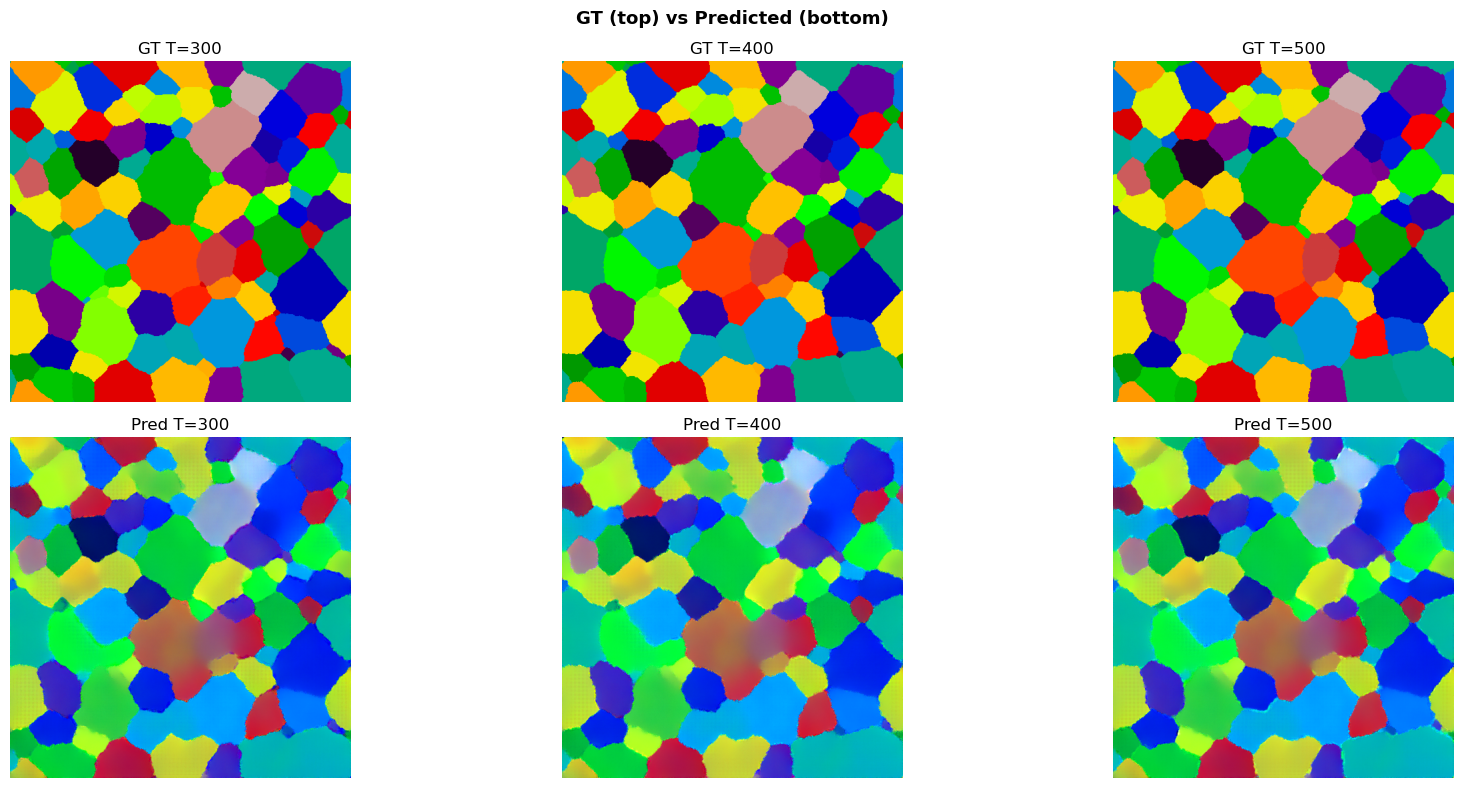

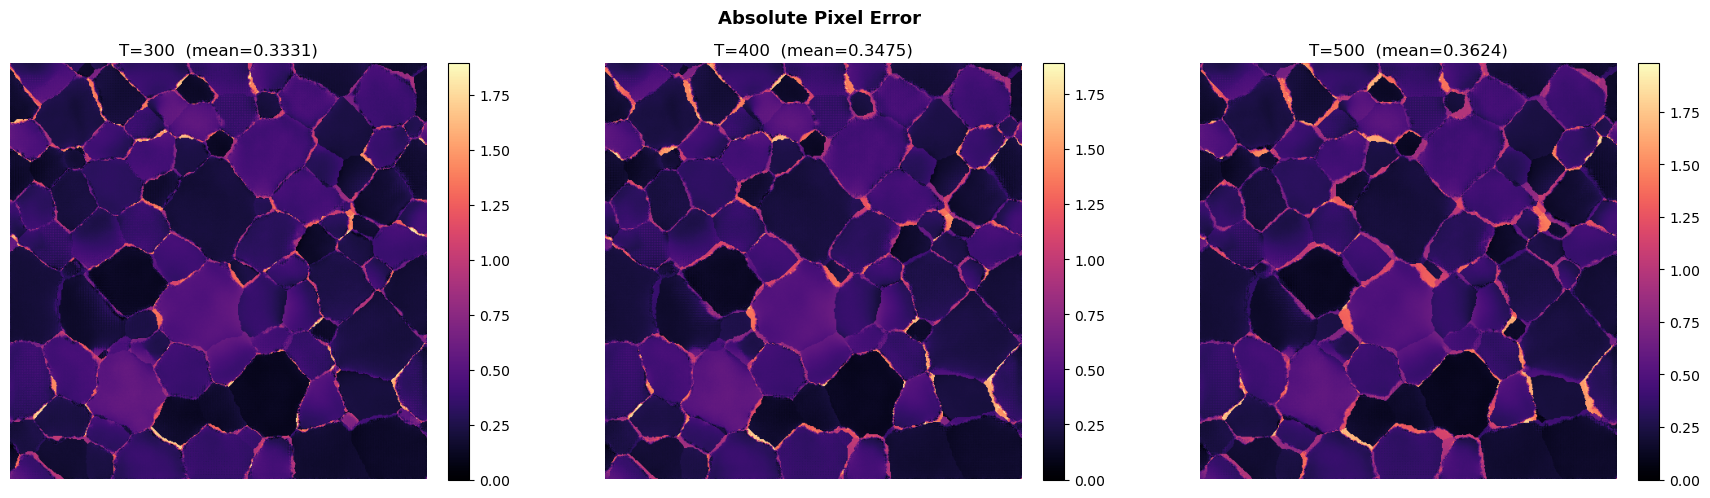

In [4]:
# ── SELECT ────────────────────────────────────────────────────────────────────
run_id          = 632
temp            = 0.515
anchor_timestep = 200
target_timesteps = [anchor_timestep + DELTA_T*(i+1) for i in range(NUM_FUTURE_FRAMES)]

print(f"Run {run_id} | Temp {temp} | Anchor T={anchor_timestep} → Predicting T={target_timesteps}")

# ── LOAD ──────────────────────────────────────────────────────────────────────
anchor      = load_rgb(run_id, temp, anchor_timestep)
gt_frames   = [load_rgb(run_id, temp, t) for t in target_timesteps]
gt_boundary = load_boundary(run_id, temp, target_timesteps[-1])

# ── INFER ─────────────────────────────────────────────────────────────────────
jump_tensor = torch.tensor([float(target_timesteps[-1] - anchor_timestep)], device=device)
temp_tensor = torch.tensor([temp], device=device)

t0           = time.time()
pred_stacked = run_inference(anchor, jump_tensor, temp_tensor, steps=1000)
elapsed      = time.time() - t0
pred_frames  = list(torch.chunk(pred_stacked, NUM_FUTURE_FRAMES, dim=1))
print(f"Done in {elapsed:.1f}s")

# ── METRICS ───────────────────────────────────────────────────────────────────
print(f"\n{'─'*65}")
print(f"{'T':<8} {'MSE':>8} {'PSNR':>10} {'SSIM':>8} {'W-Dist':>10} {'KL':>8}")
print(f"{'─'*65}")
for i, t_target in enumerate(target_timesteps):
    pred_np = to_display(pred_frames[i])
    gt_np   = to_display(gt_frames[i])
    mse     = float(np.mean((pred_np - gt_np)**2))
    psnr    = psnr_metric(gt_np, pred_np, data_range=1.0)
    ssim    = ssim_metric(gt_np, pred_np, data_range=1.0, channel_axis=-1)
    w       = wasserstein_distance(pred_np.mean(-1).ravel(), gt_np.mean(-1).ravel())
    ph, _   = np.histogram(pred_np.mean(-1).ravel(), bins=256, range=(0,1), density=True)
    gh, _   = np.histogram(gt_np.mean(-1).ravel(),   bins=256, range=(0,1), density=True)
    kl      = float(np.sum(kl_div(np.clip(gh,1e-10,None), np.clip(ph,1e-10,None))))
    print(f"T={t_target:<5} {mse:>8.4f} {psnr:>9.2f}dB {ssim:>8.4f} {w:>10.4f} {kl:>8.4f}")
print(f"{'─'*65}")

# ── VIZ 1: 6-panel (anchor | GT final | Pred final | GT boundary | pred edges | GT edges) ──
fig, axes = plt.subplots(1, 6, figsize=(28, 4))
fig.suptitle(f"Run {run_id} | Anchor T={anchor_timestep} → T={target_timesteps[-1]} "
             f"({DDIM_STEPS}-step, {elapsed:.1f}s)", fontsize=13, fontweight='bold')
panels = [
    (f"Anchor T={anchor_timestep}",        to_display(anchor),              None),
    (f"GT T={target_timesteps[-1]}",       to_display(gt_frames[-1]),       None),
    (f"Pred T={target_timesteps[-1]}",     to_display(pred_frames[-1]),     None),
    ("GT Boundary",                         gt_boundary[0,0].cpu().numpy(), "gray"),
    ("Pred Edges",                          get_sobel_edges(pred_frames[-1]),"hot"),
    ("GT Edges",                            get_sobel_edges(gt_frames[-1]), "hot"),
]
for ax, (title, img, cmap) in zip(axes, panels):
    ax.imshow(img, cmap=cmap)
    ax.set_title(title, fontsize=10); ax.axis("off")
plt.tight_layout(); plt.show()

# ── VIZ 2: all 3 frames GT vs Pred ───────────────────────────────────────────
fig, axes = plt.subplots(2, NUM_FUTURE_FRAMES, figsize=(18, 8))
fig.suptitle("GT (top) vs Predicted (bottom)", fontsize=13, fontweight='bold')
for i, t in enumerate(target_timesteps):
    axes[0,i].imshow(to_display(gt_frames[i]));   axes[0,i].set_title(f"GT T={t}");   axes[0,i].axis("off")
    axes[1,i].imshow(to_display(pred_frames[i])); axes[1,i].set_title(f"Pred T={t}"); axes[1,i].axis("off")
plt.tight_layout(); plt.show()

# ── VIZ 3: error heatmaps ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, NUM_FUTURE_FRAMES, figsize=(18, 5))
fig.suptitle("Absolute Pixel Error", fontsize=13, fontweight='bold')
for i, t in enumerate(target_timesteps):
    err = torch.abs(pred_frames[i] - gt_frames[i]).mean(dim=1)[0].cpu().numpy()
    im  = axes[i].imshow(err, cmap='magma', vmin=0)
    axes[i].set_title(f"T={t}  (mean={err.mean():.4f})"); axes[i].axis("off")
    fig.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

In [5]:
# Test with full 1000-step DDPM instead of 50-step DDIM
pred_stacked_ddpm = run_inference(
    anchor, past_ctx, jump_tensor, temp_tensor, steps=1000
)
pred_ddpm = list(torch.chunk(pred_stacked_ddpm, chunks=NUM_FUTURE_FRAMES, dim=1))

pred_np = to_display(pred_ddpm[0])
gt_np   = to_display(gt_frames[0])
ssim_full = ssim_metric(gt_np, pred_np, data_range=1.0, channel_axis=-1)
print(f"DDPM 1000-step SSIM at T=300: {ssim_full:.4f}")

NameError: name 'past_ctx' is not defined